# Chapter 20 Python Lab  
## Line Integrals and Work

This lab accompanies **Chapter 20: Line Integrals and Work**.

A line integral accumulates a quantity along a curve.  
There are two major types.

A **scalar line integral** accumulates a scalar field along a curve:

$$
\int_C f\,ds.
$$

A **vector line integral** accumulates the tangential component of a vector field along a curve:

$$
\int_C \mathbf F\cdot d\mathbf r.
$$

When $\mathbf F$ is a force field, the vector line integral computes **work**:

$$
W=\int_C \mathbf F\cdot d\mathbf r.
$$

This lab uses Python to explore:

- parametrized curves;
- arc length;
- scalar line integrals;
- work integrals;
- orientation and reparametrization;
- line integrals in vector fields;
- conservative fields and path independence;
- circulation around closed curves;
- numerical approximation of line integrals from sampled data;
- work along piecewise paths;
- and a mini-project on robot motion through a force field.

Only `numpy` and `matplotlib` are required.

## Learning goals

By the end of this lab, you should be able to:

1. parametrize curves in the plane and in space;
2. compute speed $|\mathbf r'(t)|$ and arc length;
3. approximate scalar line integrals $\int_C f\,ds$;
4. approximate work integrals $\int_C \mathbf F\cdot d\mathbf r$;
5. explain the role of curve orientation;
6. compare line integrals over different paths with the same endpoints;
7. recognize conservative fields using potentials;
8. verify the fundamental theorem for line integrals numerically;
9. compute circulation around closed curves;
10. approximate line integrals from discrete sampled paths.

## Source note

This notebook was generated from the uploaded Chapter 20 QMD file.  
The extracted early headings from the source file include:

- Learning goals
- The main idea
- Oriented curves and parameterizations
- Scalar line integrals with respect to arc length
- Scalar line integrals do not depend on orientation
- Example 1: scalar line integral over a quarter circle
- Mass of a wire
- Example 2: mass of a helical wire
- Line integrals with respect to coordinates
- $ds$ versus $dx$, $dy$, and $dz$
- Vector line integrals and work
- The computation recipe
- Example 3: work along a circular arc
- Orientation matters for vector line integrals

## 0. Setup

Run this cell first.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)
norm = np.linalg.norm

def make_grid(xmin=-3, xmax=3, ymin=-3, ymax=3, n=25):
    x = np.linspace(xmin, xmax, n)
    y = np.linspace(ymin, ymax, n)
    X, Y = np.meshgrid(x, y)
    return x, y, X, Y

def make_dense_grid(xmin=-3, xmax=3, ymin=-3, ymax=3, n=300):
    x = np.linspace(xmin, xmax, n)
    y = np.linspace(ymin, ymax, n)
    X, Y = np.meshgrid(x, y)
    return x, y, X, Y

def safe_eval_2d(f, X, Y):
    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        Z = f(X, Y)
    return np.asarray(Z, dtype=float)

def vector_magnitude(U, V):
    return np.sqrt(U**2 + V**2)

def unit_vector_field(U, V, eps=1e-12):
    M = vector_magnitude(U, V)
    return U/(M+eps), V/(M+eps), M

def plot_vector_field(F, xmin=-3, xmax=3, ymin=-3, ymax=3, n=21,
                      normalize=True, title="Vector field"):
    x, y, X, Y = make_grid(xmin, xmax, ymin, ymax, n=n)
    U, V = F(X, Y)
    M = vector_magnitude(U, V)
    if normalize:
        Uplot, Vplot, _ = unit_vector_field(U, V)
    else:
        Uplot, Vplot = U, V

    plt.figure(figsize=(7, 6))
    plt.quiver(X, Y, Uplot, Vplot, M)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.axis("equal")
    plt.grid(True, alpha=0.25)
    plt.show()
    return X, Y, U, V, M

def plot_scalar_contours(f, xmin=-3, xmax=3, ymin=-3, ymax=3, n=300,
                         levels=20, title="Scalar field contours", path=None):
    x, y, X, Y = make_dense_grid(xmin, xmax, ymin, ymax, n=n)
    Z = safe_eval_2d(f, X, Y)
    plt.figure(figsize=(7, 6))
    cs = plt.contour(X, Y, Z, levels=levels)
    plt.clabel(cs, inline=True, fontsize=8)
    if path is not None:
        plt.plot(path[:,0], path[:,1], linewidth=3)
        plt.scatter([path[0,0]], [path[0,1]], s=70, label="start")
        plt.scatter([path[-1,0]], [path[-1,1]], s=70, label="end")
        plt.legend()
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.axis("equal")
    plt.grid(True, alpha=0.25)
    plt.show()
    return X, Y, Z

def finite_difference_path(r, t):
    """
    Numerically approximate r'(t) from sampled r(t).
    """
    X, Y = r(t)
    dX = np.gradient(X, t)
    dY = np.gradient(Y, t)
    return dX, dY

def scalar_line_integral(f, r, rp, a, b, n=2000):
    t = np.linspace(a, b, n)
    X, Y = r(t)
    dX, dY = rp(t)
    speed = np.sqrt(dX**2 + dY**2)
    values = safe_eval_2d(f, X, Y)
    integrand = values*speed
    return float(np.trapezoid(integrand, t)), t, values, speed, integrand

def vector_line_integral(F, r, rp, a, b, n=2000):
    t = np.linspace(a, b, n)
    X, Y = r(t)
    dX, dY = rp(t)
    P, Q = F(X, Y)
    integrand = P*dX + Q*dY
    return float(np.trapezoid(integrand, t)), t, P, Q, dX, dY, integrand

def arc_length(rp, a, b, n=2000):
    t = np.linspace(a, b, n)
    dX, dY = rp(t)
    speed = np.sqrt(dX**2 + dY**2)
    return float(np.trapezoid(speed, t)), t, speed

def plot_curve(r, a, b, xmin=-3, xmax=3, ymin=-3, ymax=3, title="Parametrized curve",
               arrows=True, n=400):
    t = np.linspace(a, b, n)
    X, Y = r(t)
    plt.figure(figsize=(7, 6))
    plt.plot(X, Y, linewidth=3)
    plt.scatter([X[0]], [Y[0]], s=80, label="start")
    plt.scatter([X[-1]], [Y[-1]], s=80, label="end")
    if arrows:
        idxs = np.linspace(30, n-30, 5, dtype=int)
        for idx in idxs:
            dx = X[idx+1] - X[idx-1]
            dy = Y[idx+1] - Y[idx-1]
            L = np.sqrt(dx**2 + dy**2)
            if L > 0:
                plt.arrow(X[idx], Y[idx], 0.18*dx/L, 0.18*dy/L,
                          head_width=0.07, length_includes_head=True)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.axis("equal")
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.show()
    return np.column_stack([X, Y])

def plot_path_in_vector_field(F, r, a, b, xmin=-3, xmax=3, ymin=-3, ymax=3,
                              title="Path in vector field", normalize=True):
    x, y, X, Y = make_grid(xmin, xmax, ymin, ymax, n=21)
    U, V = F(X, Y)
    if normalize:
        U, V, _ = unit_vector_field(U, V)
    t = np.linspace(a, b, 500)
    Xp, Yp = r(t)
    plt.figure(figsize=(7, 6))
    plt.quiver(X, Y, U, V, alpha=0.45)
    plt.plot(Xp, Yp, linewidth=3)
    plt.scatter([Xp[0]], [Yp[0]], s=80, label="start")
    plt.scatter([Xp[-1]], [Yp[-1]], s=80, label="end")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.axis("equal")
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)
    plt.legend()
    plt.grid(True, alpha=0.25)
    plt.show()

def sampled_scalar_line_integral(f, points):
    """
    Approximate ∫ f ds along a polyline through sampled points.
    """
    points = np.asarray(points, dtype=float)
    segments = points[1:] - points[:-1]
    ds = np.sqrt(np.sum(segments**2, axis=1))
    midpoints = 0.5*(points[1:] + points[:-1])
    values = f(midpoints[:,0], midpoints[:,1])
    return float(np.sum(values*ds)), midpoints, ds, values

def sampled_vector_line_integral(F, points):
    """
    Approximate ∫ F·dr along a polyline through sampled points.
    """
    points = np.asarray(points, dtype=float)
    dr = points[1:] - points[:-1]
    midpoints = 0.5*(points[1:] + points[:-1])
    P, Q = F(midpoints[:,0], midpoints[:,1])
    contributions = P*dr[:,0] + Q*dr[:,1]
    return float(np.sum(contributions)), midpoints, dr, contributions

def piecewise_points(vertices, points_per_segment=200):
    """
    Create a sampled polyline from ordered vertices.
    """
    vertices = np.asarray(vertices, dtype=float)
    pts = []
    for i in range(len(vertices)-1):
        a = vertices[i]
        b = vertices[i+1]
        t = np.linspace(0, 1, points_per_segment, endpoint=False)
        segment = a[None,:] + t[:,None]*(b-a)[None,:]
        pts.append(segment)
    pts.append(vertices[-1][None,:])
    return np.vstack(pts)

print("Setup complete.")

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-km5yxyuf because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Setup complete.


---

# Part I. Parametrized curves and arc length

A curve $C$ is often described by a parametrization

$$
\mathbf r(t)=\langle x(t),y(t)\rangle,
\qquad a\leq t\leq b.
$$

The velocity is

$$
\mathbf r'(t)=\langle x'(t),y'(t)\rangle,
$$

and the speed is

$$
|\mathbf r'(t)|=\sqrt{(x'(t))^2+(y'(t))^2}.
$$

The arc length is

$$
L=\int_a^b |\mathbf r'(t)|\,dt.
$$

## 1. Line segment from $A=(0,0)$ to $B=(3,4)$

Use

$$
\mathbf r(t)=\langle 3t,4t\rangle,\qquad 0\leq t\leq1.
$$

The exact arc length is $5$.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


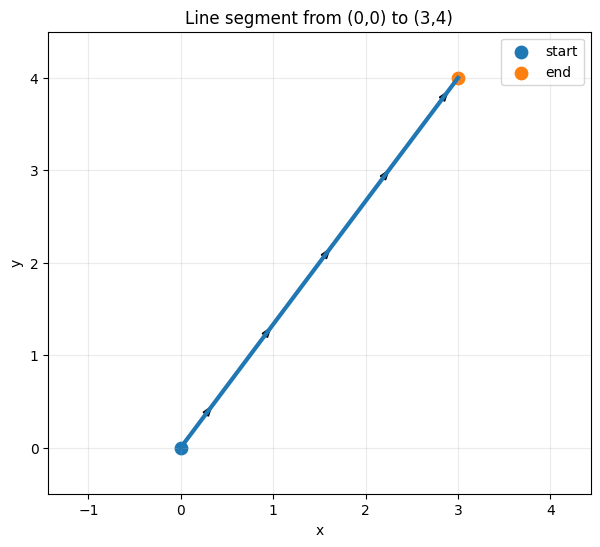

Arc length estimate: 5.0
Exact arc length: 5
Speed values are constant: [5.]


In [2]:
def r_segment(t):
    return 3*t, 4*t

def rp_segment(t):
    return 3*np.ones_like(t), 4*np.ones_like(t)

path_segment = plot_curve(
    r_segment, 0, 1,
    xmin=-0.5, xmax=3.5, ymin=-0.5, ymax=4.5,
    title="Line segment from (0,0) to (3,4)"
)

L_segment, t, speed_segment = arc_length(rp_segment, 0, 1)
print("Arc length estimate:", L_segment)
print("Exact arc length:", 5)
print("Speed values are constant:", np.unique(np.round(speed_segment, 8))[:5])

## 2. Circle of radius $R$

Use

$$
\mathbf r(t)=\langle R\cos t,R\sin t\rangle,
\qquad 0\leq t\leq 2\pi.
$$

The exact length is $2\pi R$.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


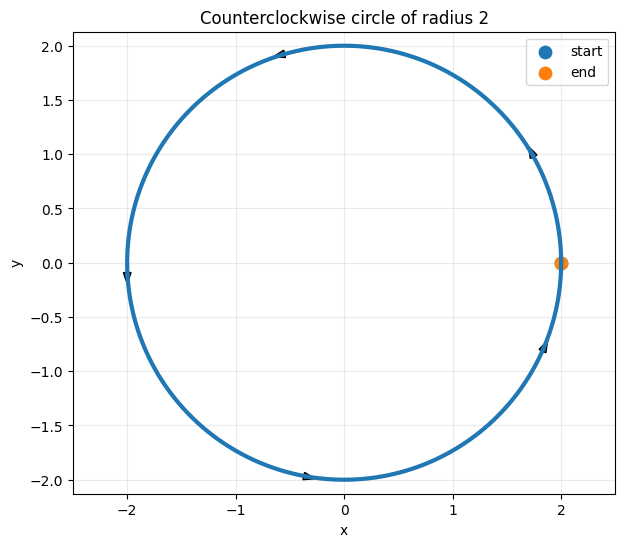

Arc length estimate: 12.566370614359172
Exact circumference: 12.566370614359172
Maximum speed variation: 2.220446049250313e-16


In [3]:
R = 2.0

def r_circle(t):
    return R*np.cos(t), R*np.sin(t)

def rp_circle(t):
    return -R*np.sin(t), R*np.cos(t)

path_circle = plot_curve(
    r_circle, 0, 2*np.pi,
    xmin=-2.5, xmax=2.5, ymin=-2.5, ymax=2.5,
    title="Counterclockwise circle of radius 2"
)

L_circle, t, speed_circle = arc_length(rp_circle, 0, 2*np.pi)

print("Arc length estimate:", L_circle)
print("Exact circumference:", 2*np.pi*R)
print("Maximum speed variation:", np.max(speed_circle)-np.min(speed_circle))

## 3. A nonlinear curve

Consider the parabola

$$
\mathbf r(t)=\langle t,t^2\rangle,\qquad 0\leq t\leq2.
$$

The speed is

$$
|\mathbf r'(t)|=\sqrt{1+4t^2}.
$$

In [4]:
def r_parabola(t):
    return t, t**2

def rp_parabola(t):
    return np.ones_like(t), 2*t

path_parabola = plot_curve(
    r_parabola, 0, 2,
    xmin=-0.2, xmax=2.2, ymin=-0.2, ymax=4.3,
    title=r"Parabola $\mathbf r(t)=\langle t,t^2\rangle$"
)

L_parabola, t, speed_parabola = arc_length(rp_parabola, 0, 2)

plt.figure(figsize=(7, 4))
plt.plot(t, speed_parabola)
plt.xlabel("t")
plt.ylabel("speed")
plt.title(r"Speed $|\mathbf r'(t)|=\sqrt{1+4t^2}$")
plt.grid(True, alpha=0.25)
plt.show()

print("Parabola arc length estimate:", L_parabola)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


ValueError: 
\mathbf r(t)=\langle t,t^2\rangle
^
ParseFatalException: Unknown symbol: \mathbf, found '\'  (at char 0), (line:1, col:1)

<Figure size 700x600 with 1 Axes>

ValueError: 
|\mathbf r'(t)|=\sqrt{1+4t^2}
 ^
ParseFatalException: Unknown symbol: \mathbf, found '\'  (at char 1), (line:1, col:2)

<Figure size 700x400 with 1 Axes>

Parabola arc length estimate: 4.646783924285165


---

# Part II. Scalar line integrals

A scalar line integral has the form

$$
\int_C f(x,y)\,ds.
$$

Using a parametrization $\mathbf r(t)$,

$$
\int_C f\,ds
=
\int_a^b f(\mathbf r(t))|\mathbf r'(t)|\,dt.
$$

Interpretations include:

- mass of a wire with linear density $f$;
- accumulated temperature along a path;
- total exposure along a route;
- weighted length.

## 4. Scalar line integral over a line segment

Let

$$
f(x,y)=x+y
$$

and let $C$ be the line segment from $(0,0)$ to $(3,4)$.

Using $\mathbf r(t)=\langle 3t,4t\rangle$,

$$
f(\mathbf r(t))=7t,
\qquad
|\mathbf r'(t)|=5.
$$

So

$$
\int_C f\,ds=\int_0^1 35t\,dt=\frac{35}{2}.
$$

In [5]:
def f_linear(X, Y):
    return X + Y

I_scalar_segment, t, values, speed, integrand = scalar_line_integral(
    f_linear, r_segment, rp_segment, 0, 1
)

print("Scalar line integral estimate:", I_scalar_segment)
print("Exact value:", 35/2)

plt.figure(figsize=(7, 4))
plt.plot(t, values, label=r"$f(\mathbf r(t))$")
plt.plot(t, speed, label=r"$|\mathbf r'(t)|$")
plt.plot(t, integrand, label=r"$f(\mathbf r(t))|\mathbf r'(t)|$")
plt.xlabel("t")
plt.title("Scalar line-integral components")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

Scalar line integral estimate: 17.5
Exact value: 17.5


ValueError: 
f(\mathbf r(t))
  ^
ParseFatalException: Unknown symbol: \mathbf, found '\'  (at char 2), (line:1, col:3)

<Figure size 700x400 with 1 Axes>

## 5. Scalar line integral over a circle

Let

$$
f(x,y)=x^2+y^2.
$$

On a circle of radius $R=2$, we have $f=4$ and $ds=2\,dt$. Therefore

$$
\int_C f\,ds=4(2\pi R)=16\pi.
$$

In [6]:
def f_radius_squared(X, Y):
    return X**2 + Y**2

I_scalar_circle, t, values, speed, integrand = scalar_line_integral(
    f_radius_squared, r_circle, rp_circle, 0, 2*np.pi
)

print("Scalar line integral estimate:", I_scalar_circle)
print("Exact value:", 16*np.pi)

Scalar line integral estimate: 50.26548245743669
Exact value: 50.26548245743669


## 6. Wire mass with variable density

Suppose a wire follows the parabola

$$
\mathbf r(t)=\langle t,t^2\rangle,\qquad 0\leq t\leq2,
$$

and has density

$$
\rho(x,y)=1+0.2x+0.1y.
$$

The mass is

$$
m=\int_C \rho\,ds.
$$

Wire mass estimate: 6.645448384298745


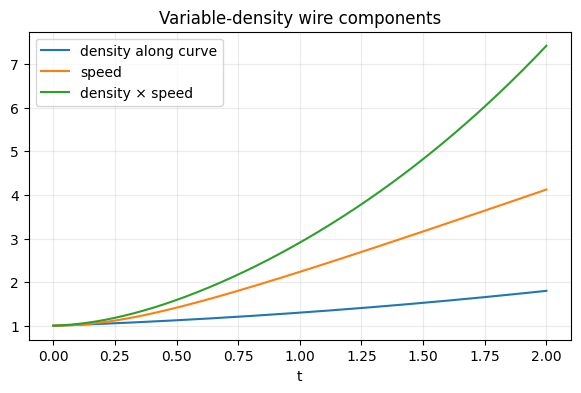

In [7]:
def density_wire(X, Y):
    return 1 + 0.2*X + 0.1*Y

mass_wire, t, rho_values, speed_values, integrand = scalar_line_integral(
    density_wire, r_parabola, rp_parabola, 0, 2
)

print("Wire mass estimate:", mass_wire)

plt.figure(figsize=(7, 4))
plt.plot(t, rho_values, label="density along curve")
plt.plot(t, speed_values, label="speed")
plt.plot(t, integrand, label="density × speed")
plt.xlabel("t")
plt.title("Variable-density wire components")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

### Guided task 1

Compute

$$
\int_C (1+x^2)\,ds
$$

where $C$ is the upper semicircle

$$
\mathbf r(t)=\langle \cos t,\sin t\rangle,
\qquad 0\leq t\leq\pi.
$$

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Numerical value: 4.71238898038469
Exact value: 4.71238898038469


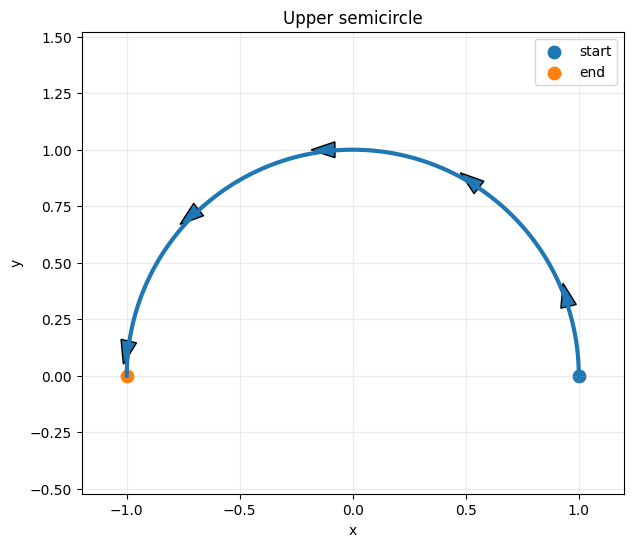

array([[ 1.      ,  0.      ],
       [ 0.999969,  0.007874],
       [ 0.999876,  0.015747],
       [ 0.999721,  0.023619],
       [ 0.999504,  0.031489],
       [ 0.999225,  0.039358],
       [ 0.998884,  0.047224],
       [ 0.998482,  0.055088],
       [ 0.998017,  0.062948],
       [ 0.99749 ,  0.070804],
       [ 0.996902,  0.078655],
       [ 0.996252,  0.086502],
       [ 0.99554 ,  0.094343],
       [ 0.994766,  0.102179],
       [ 0.993931,  0.110008],
       [ 0.993034,  0.117831],
       [ 0.992075,  0.125646],
       [ 0.991055,  0.133453],
       [ 0.989974,  0.141252],
       [ 0.988831,  0.149042],
       [ 0.987627,  0.156823],
       [ 0.986361,  0.164595],
       [ 0.985035,  0.172356],
       [ 0.983647,  0.180106],
       [ 0.982199,  0.187845],
       [ 0.980689,  0.195573],
       [ 0.979119,  0.203288],
       [ 0.977488,  0.210991],
       [ 0.975796,  0.218681],
       [ 0.974044,  0.226357],
       [ 0.972232,  0.23402 ],
       [ 0.970359,  0.241667],
       [

In [8]:
def r_semicircle(t):
    return np.cos(t), np.sin(t)

def rp_semicircle(t):
    return -np.sin(t), np.cos(t)

def f_task1(X, Y):
    return 1 + X**2

I_task1, *_ = scalar_line_integral(f_task1, r_semicircle, rp_semicircle, 0, np.pi)

# Exact: ∫_0^π (1+cos^2 t) dt = π + π/2 = 3π/2.
print("Numerical value:", I_task1)
print("Exact value:", 3*np.pi/2)

plot_curve(
    r_semicircle, 0, np.pi,
    xmin=-1.2, xmax=1.2, ymin=-0.2, ymax=1.2,
    title="Upper semicircle"
)

---

# Part III. Vector line integrals and work

For a vector field

$$
\mathbf F(x,y)=\langle P(x,y),Q(x,y)\rangle,
$$

the vector line integral along $\mathbf r(t)$ is

$$
\int_C \mathbf F\cdot d\mathbf r
=
\int_a^b \mathbf F(\mathbf r(t))\cdot \mathbf r'(t)\,dt.
$$

If $\mathbf F$ is a force field, this integral is the work done by the force on a particle moving along $C$.

## 7. Constant force along a line segment

Let

$$
\mathbf F=\langle 2,1\rangle
$$

and move from $(0,0)$ to $(3,4)$.

The displacement is $\langle 3,4\rangle$, so the work is

$$
\mathbf F\cdot \Delta \mathbf r
=
\langle 2,1\rangle\cdot\langle 3,4\rangle
=
10.
$$

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Work estimate: 10.0
Exact work: 10


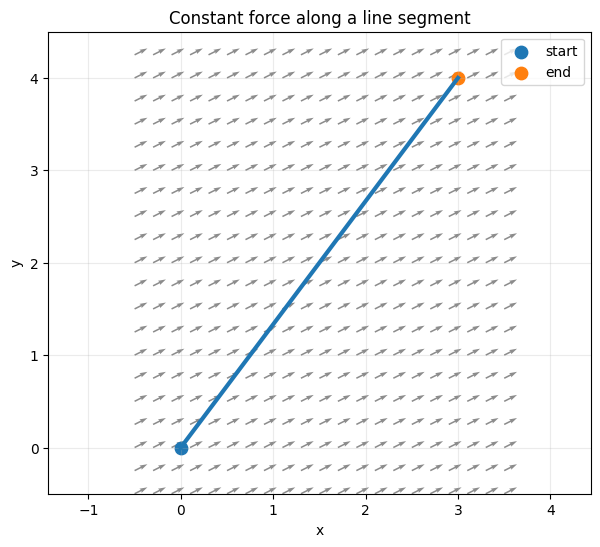

In [9]:
def F_constant(X, Y):
    return 2*np.ones_like(X), np.ones_like(Y)

W_constant, t, P, Q, dX, dY, integrand = vector_line_integral(
    F_constant, r_segment, rp_segment, 0, 1
)

print("Work estimate:", W_constant)
print("Exact work:", 10)

plot_path_in_vector_field(
    F_constant,
    r_segment,
    0, 1,
    xmin=-0.5, xmax=3.5,
    ymin=-0.5, ymax=4.5,
    title=r"Constant force along a line segment"
)

## 8. Radial field along a radial path

Let

$$
\mathbf F(x,y)=\langle x,y\rangle
$$

and move from $(0,0)$ to $(3,4)$.

This is the gradient field of

$$
f(x,y)=\frac12(x^2+y^2).
$$

Therefore the work should be

$$
f(3,4)-f(0,0)=\frac12(3^2+4^2)=\frac{25}{2}.
$$

In [10]:
def F_radial(X, Y):
    return X, Y

def potential_radial(X, Y):
    return 0.5*(X**2 + Y**2)

W_radial, t, P, Q, dX, dY, integrand = vector_line_integral(
    F_radial, r_segment, rp_segment, 0, 1
)

print("Work estimate:", W_radial)
print("Potential difference:", potential_radial(3,4)-potential_radial(0,0))

plt.figure(figsize=(7, 4))
plt.plot(t, integrand)
plt.xlabel("t")
plt.ylabel(r"$\mathbf F(\mathbf r(t))\cdot\mathbf r'(t)$")
plt.title("Work integrand for radial field along radial path")
plt.grid(True, alpha=0.25)
plt.show()

Work estimate: 12.5
Potential difference: 12.5


ValueError: 
\mathbf F(\mathbf r(t))\cdot\mathbf r'(t)
^
ParseFatalException: Unknown symbol: \mathbf, found '\'  (at char 0), (line:1, col:1)

<Figure size 700x400 with 1 Axes>

## 9. Work can be negative

If the force points against the direction of motion, the work is negative.

Let

$$
\mathbf F=\langle -1,0\rangle
$$

and move from $(0,0)$ to $(3,0)$.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Work estimate: -3.0
Exact work: -3


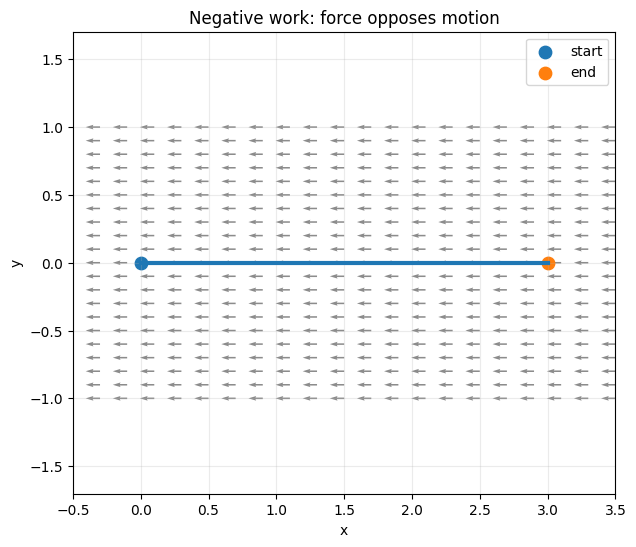

In [11]:
def r_xaxis(t):
    return 3*t, 0*t

def rp_xaxis(t):
    return 3*np.ones_like(t), 0*t

def F_left(X, Y):
    return -np.ones_like(X), 0*np.ones_like(Y)

W_left, *_ = vector_line_integral(F_left, r_xaxis, rp_xaxis, 0, 1)

print("Work estimate:", W_left)
print("Exact work:", -3)

plot_path_in_vector_field(
    F_left,
    r_xaxis,
    0, 1,
    xmin=-0.5, xmax=3.5,
    ymin=-1, ymax=1,
    title="Negative work: force opposes motion"
)

---

# Part IV. Orientation matters for vector line integrals

For scalar line integrals $\int_C f\,ds$, reversing direction does not change the value.

For vector line integrals $\int_C \mathbf F\cdot d\mathbf r$, reversing direction changes the sign.

## 10. Reverse a path

In [12]:
def r_segment_reverse(t):
    return 3*(1-t), 4*(1-t)

def rp_segment_reverse(t):
    return -3*np.ones_like(t), -4*np.ones_like(t)

I_forward, *_ = scalar_line_integral(f_linear, r_segment, rp_segment, 0, 1)
I_reverse, *_ = scalar_line_integral(f_linear, r_segment_reverse, rp_segment_reverse, 0, 1)

W_forward, *_ = vector_line_integral(F_radial, r_segment, rp_segment, 0, 1)
W_reverse, *_ = vector_line_integral(F_radial, r_segment_reverse, rp_segment_reverse, 0, 1)

print("Scalar line integral forward:", I_forward)
print("Scalar line integral reverse:", I_reverse)
print()
print("Vector line integral forward:", W_forward)
print("Vector line integral reverse:", W_reverse)
print("Sum of vector integrals:", W_forward + W_reverse)

Scalar line integral forward: 17.5
Scalar line integral reverse: 17.5

Vector line integral forward: 12.5
Vector line integral reverse: -12.5
Sum of vector integrals: 0.0


## 11. Visual comparison of forward and reverse orientation

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


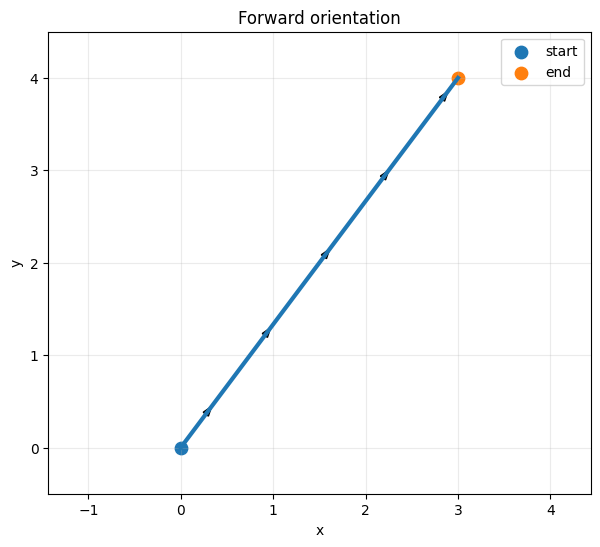

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


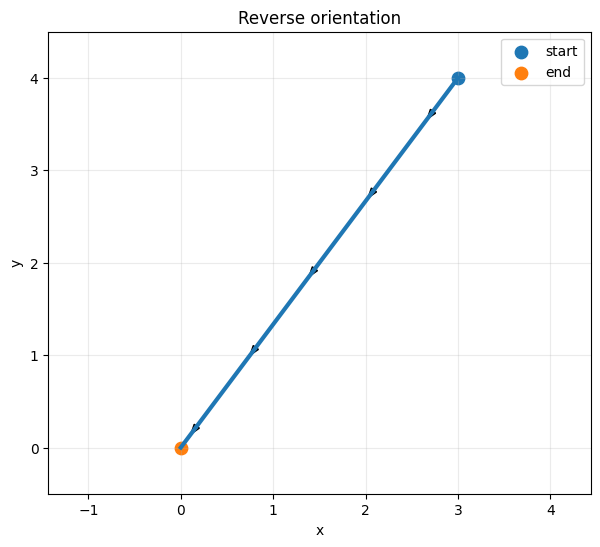

array([[3.      , 4.      ],
       [2.992481, 3.989975],
       [2.984962, 3.97995 ],
       [2.977444, 3.969925],
       [2.969925, 3.9599  ],
       [2.962406, 3.949875],
       [2.954887, 3.93985 ],
       [2.947368, 3.929825],
       [2.93985 , 3.919799],
       [2.932331, 3.909774],
       [2.924812, 3.899749],
       [2.917293, 3.889724],
       [2.909774, 3.879699],
       [2.902256, 3.869674],
       [2.894737, 3.859649],
       [2.887218, 3.849624],
       [2.879699, 3.839599],
       [2.87218 , 3.829574],
       [2.864662, 3.819549],
       [2.857143, 3.809524],
       [2.849624, 3.799499],
       [2.842105, 3.789474],
       [2.834586, 3.779449],
       [2.827068, 3.769424],
       [2.819549, 3.759398],
       [2.81203 , 3.749373],
       [2.804511, 3.739348],
       [2.796992, 3.729323],
       [2.789474, 3.719298],
       [2.781955, 3.709273],
       [2.774436, 3.699248],
       [2.766917, 3.689223],
       [2.759398, 3.679198],
       [2.75188 , 3.669173],
       [2.7443

In [13]:
plot_curve(
    r_segment, 0, 1,
    xmin=-0.5, xmax=3.5, ymin=-0.5, ymax=4.5,
    title="Forward orientation"
)

plot_curve(
    r_segment_reverse, 0, 1,
    xmin=-0.5, xmax=3.5, ymin=-0.5, ymax=4.5,
    title="Reverse orientation"
)

---

# Part V. Reparametrization

Changing the speed of a parametrization should not change the value of a line integral, as long as the curve and orientation are the same.

For example, the segment from $(0,0)$ to $(3,4)$ can be parametrized by

$$
\mathbf r_1(t)=\langle 3t,4t\rangle,\qquad 0\leq t\leq1,
$$

or by

$$
\mathbf r_2(s)=\langle 3s^2,4s^2\rangle,\qquad 0\leq s\leq1.
$$

The second parametrization moves slowly at first and faster later, but traces the same oriented curve.

In [14]:
def r_segment_slowfast(s):
    return 3*s**2, 4*s**2

def rp_segment_slowfast(s):
    return 6*s, 8*s

I1, *_ = scalar_line_integral(f_linear, r_segment, rp_segment, 0, 1)
I2, *_ = scalar_line_integral(f_linear, r_segment_slowfast, rp_segment_slowfast, 0, 1)

W1, *_ = vector_line_integral(F_radial, r_segment, rp_segment, 0, 1)
W2, *_ = vector_line_integral(F_radial, r_segment_slowfast, rp_segment_slowfast, 0, 1)

print("Scalar integral with standard parametrization:", I1)
print("Scalar integral with slow-fast parametrization:", I2)
print()
print("Vector integral with standard parametrization:", W1)
print("Vector integral with slow-fast parametrization:", W2)

Scalar integral with standard parametrization: 17.5
Scalar integral with slow-fast parametrization: 17.500004379378286

Vector integral with standard parametrization: 12.5
Vector integral with slow-fast parametrization: 12.500003128127343


---

# Part VI. Conservative fields and path independence

If

$$
\mathbf F=\nabla f,
$$

then

$$
\int_C\mathbf F\cdot d\mathbf r=f(B)-f(A),
$$

where $A$ and $B$ are the starting and ending points of $C$.

This is the **fundamental theorem for line integrals**.

## 12. Two different paths in a conservative field

Let

$$
\mathbf F(x,y)=\langle 2x,2y\rangle=\nabla(x^2+y^2).
$$

Move from $A=(0,0)$ to $B=(1,1)$ along:

1. a straight line;
2. a parabola.

In [15]:
def F_bowl(X, Y):
    return 2*X, 2*Y

def potential_bowl(X, Y):
    return X**2 + Y**2

def r_straight_01(t):
    return t, t

def rp_straight_01(t):
    return np.ones_like(t), np.ones_like(t)

def r_parabola_01(t):
    return t, t**2

def rp_parabola_01(t):
    return np.ones_like(t), 2*t

W_straight, *_ = vector_line_integral(F_bowl, r_straight_01, rp_straight_01, 0, 1)
W_parabola, *_ = vector_line_integral(F_bowl, r_parabola_01, rp_parabola_01, 0, 1)
delta_potential = potential_bowl(1,1) - potential_bowl(0,0)

print("Work along straight line:", W_straight)
print("Work along parabola:", W_parabola)
print("Potential difference:", delta_potential)

Work along straight line: 2.0
Work along parabola: 2.0000002502501877
Potential difference: 2


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


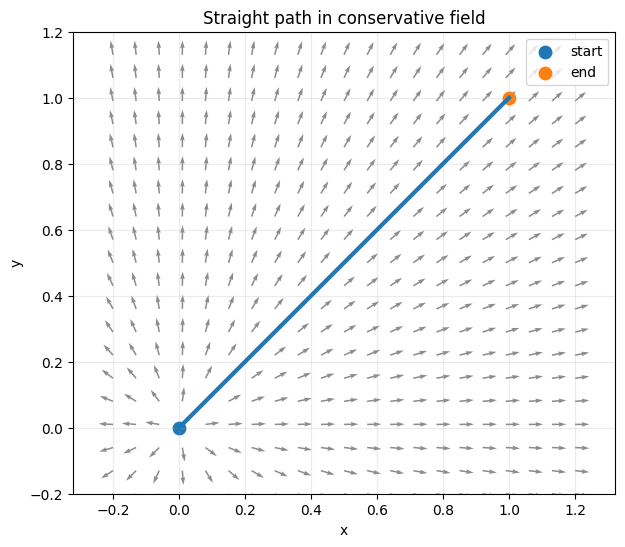

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


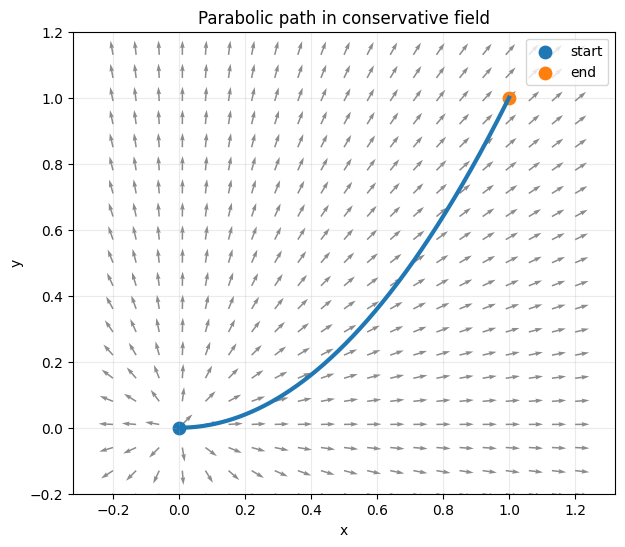

In [16]:
plot_path_in_vector_field(
    F_bowl,
    r_straight_01,
    0, 1,
    xmin=-0.2, xmax=1.2,
    ymin=-0.2, ymax=1.2,
    title="Straight path in conservative field"
)

plot_path_in_vector_field(
    F_bowl,
    r_parabola_01,
    0, 1,
    xmin=-0.2, xmax=1.2,
    ymin=-0.2, ymax=1.2,
    title="Parabolic path in conservative field"
)

## 13. Nonconservative field: path dependence

Let

$$
\mathbf F(x,y)=\langle -y,x\rangle.
$$

This rotational field is not a gradient field on the plane.

Again compare the straight path and parabolic path from $(0,0)$ to $(1,1)$.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Rotational field work along straight line: 0.0
Rotational field work along parabola: 0.33333337504169797
Difference: 0.33333337504169797


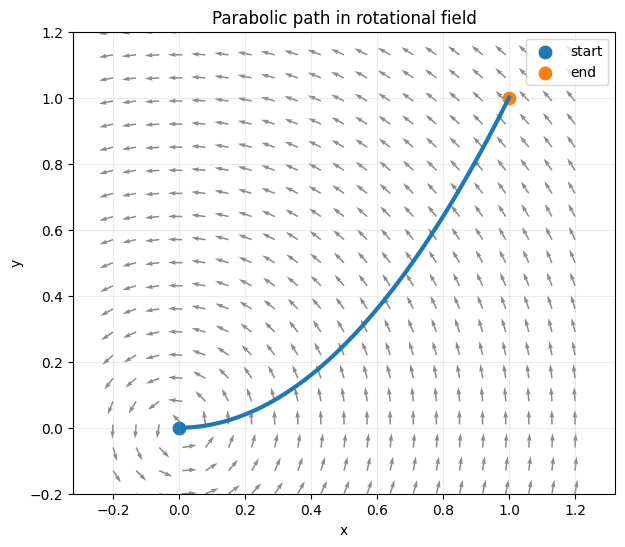

In [17]:
def F_rotational(X, Y):
    return -Y, X

W_rot_straight, *_ = vector_line_integral(F_rotational, r_straight_01, rp_straight_01, 0, 1)
W_rot_parabola, *_ = vector_line_integral(F_rotational, r_parabola_01, rp_parabola_01, 0, 1)

print("Rotational field work along straight line:", W_rot_straight)
print("Rotational field work along parabola:", W_rot_parabola)
print("Difference:", W_rot_parabola - W_rot_straight)

plot_path_in_vector_field(
    F_rotational,
    r_parabola_01,
    0, 1,
    xmin=-0.2, xmax=1.2,
    ymin=-0.2, ymax=1.2,
    title="Parabolic path in rotational field"
)

---

# Part VII. Circulation around closed curves

For a closed curve $C$, the vector line integral

$$
\oint_C \mathbf F\cdot d\mathbf r
$$

is often called **circulation**.

For a conservative field, circulation around every closed curve is zero.

For a rotational field, circulation can be nonzero.

## 14. Circulation around a circle

Let

$$
\mathbf F(x,y)=\langle -y,x\rangle
$$

and

$$
\mathbf r(t)=\langle R\cos t,R\sin t\rangle,
\qquad 0\leq t\leq2\pi.
$$

Then

$$
\mathbf F(\mathbf r(t))=\langle -R\sin t,R\cos t\rangle=\mathbf r'(t).
$$

So

$$
\oint_C \mathbf F\cdot d\mathbf r
=
\int_0^{2\pi} R^2\,dt
=
2\pi R^2.
$$

In [18]:
for Rtest in [0.5, 1.0, 2.0, 3.0]:
    def r_circle_R(t, Rtest=Rtest):
        return Rtest*np.cos(t), Rtest*np.sin(t)
    def rp_circle_R(t, Rtest=Rtest):
        return -Rtest*np.sin(t), Rtest*np.cos(t)
    W, *_ = vector_line_integral(F_rotational, r_circle_R, rp_circle_R, 0, 2*np.pi, n=4000)
    print(f"R={Rtest:3.1f}, circulation={W:12.6f}, exact={2*np.pi*Rtest**2:12.6f}")

R=0.5, circulation=    1.570796, exact=    1.570796
R=1.0, circulation=    6.283185, exact=    6.283185
R=2.0, circulation=   25.132741, exact=   25.132741
R=3.0, circulation=   56.548668, exact=   56.548668


## 15. Closed curve in a conservative field

In [19]:
W_bowl_circle, *_ = vector_line_integral(F_bowl, r_circle, rp_circle, 0, 2*np.pi, n=4000)

print("Circulation of gradient field around circle:", W_bowl_circle)
print("Expected value:", 0)

Circulation of gradient field around circle: 0.0
Expected value: 0


### Guided task 2

Compute the circulation of

$$
\mathbf F(x,y)=\langle y,0\rangle
$$

around the unit circle counterclockwise.

Compare it with the circulation of $\langle -y,x\rangle$.

In [20]:
def F_task2(X, Y):
    return Y, 0*X

def r_unit_circle(t):
    return np.cos(t), np.sin(t)

def rp_unit_circle(t):
    return -np.sin(t), np.cos(t)

I_task2, *_ = vector_line_integral(F_task2, r_unit_circle, rp_unit_circle, 0, 2*np.pi, n=4000)
I_rot_unit, *_ = vector_line_integral(F_rotational, r_unit_circle, rp_unit_circle, 0, 2*np.pi, n=4000)

print("Circulation of <y,0> around unit circle:", I_task2)
print("Exact value for <y,0>:", -np.pi)
print("Circulation of <-y,x> around unit circle:", I_rot_unit)
print("Exact value for <-y,x>:", 2*np.pi)

Circulation of <y,0> around unit circle: -3.141592653589793
Exact value for <y,0>: -3.141592653589793
Circulation of <-y,x> around unit circle: 6.283185307179586
Exact value for <-y,x>: 6.283185307179586


---

# Part VIII. Piecewise paths

Many paths are naturally piecewise: first move horizontally, then vertically, or follow several line segments.

A line integral over a piecewise path is the sum of the line integrals over each segment.

## 16. Piecewise path from $(0,0)$ to $(1,1)$

Compare two piecewise paths:

- Path A: $(0,0)\to(1,0)\to(1,1)$;
- Path B: $(0,0)\to(0,1)\to(1,1)$.

For a conservative field, the work is the same.  
For a rotational field, the work can differ.

Conservative field:
  Path A work: 2.0
  Path B work: 2.0

Rotational field:
  Path A work: 1.0
  Path B work: -1.0


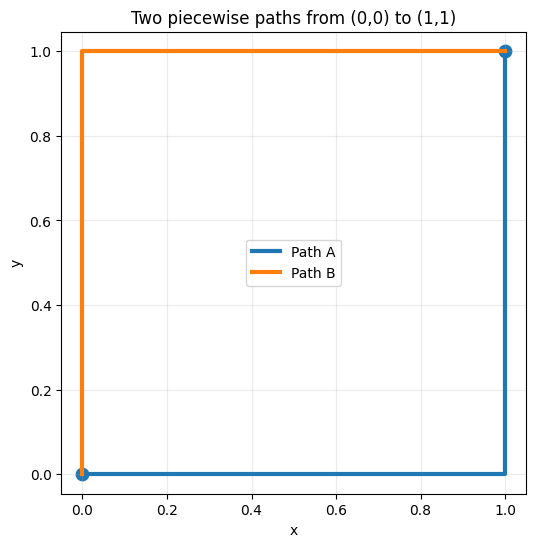

In [21]:
path_A = piecewise_points([[0,0], [1,0], [1,1]], points_per_segment=400)
path_B = piecewise_points([[0,0], [0,1], [1,1]], points_per_segment=400)

W_A_bowl, *_ = sampled_vector_line_integral(F_bowl, path_A)
W_B_bowl, *_ = sampled_vector_line_integral(F_bowl, path_B)

W_A_rot, *_ = sampled_vector_line_integral(F_rotational, path_A)
W_B_rot, *_ = sampled_vector_line_integral(F_rotational, path_B)

print("Conservative field:")
print("  Path A work:", W_A_bowl)
print("  Path B work:", W_B_bowl)
print()
print("Rotational field:")
print("  Path A work:", W_A_rot)
print("  Path B work:", W_B_rot)

plt.figure(figsize=(6, 6))
plt.plot(path_A[:,0], path_A[:,1], linewidth=3, label="Path A")
plt.plot(path_B[:,0], path_B[:,1], linewidth=3, label="Path B")
plt.scatter([0,1], [0,1], s=80)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Two piecewise paths from (0,0) to (1,1)")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

---

# Part IX. Line integrals from sampled data

In applications, a path may be known only through measured points:

$$
(x_0,y_0),(x_1,y_1),\ldots,(x_n,y_n).
$$

A scalar line integral can be approximated by

$$
\sum_i f(\text{midpoint}_i)\Delta s_i.
$$

A vector line integral can be approximated by

$$
\sum_i \mathbf F(\text{midpoint}_i)\cdot \Delta\mathbf r_i.
$$

## 17. Sampled noisy path

We create a noisy path and approximate line integrals from the sampled points.

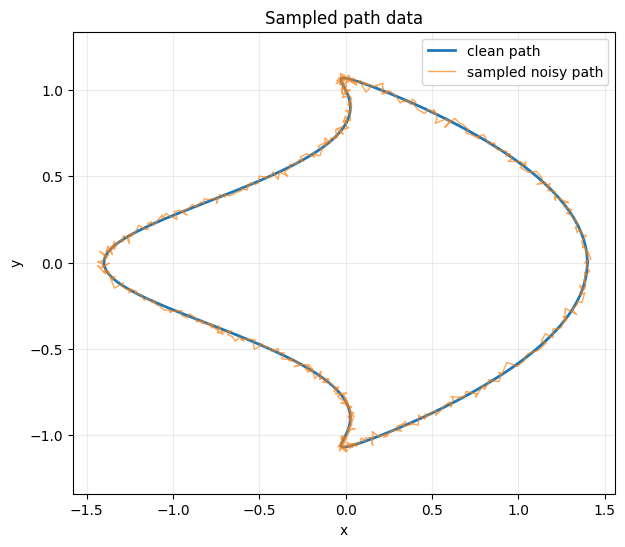

In [22]:
rng = np.random.default_rng(20)

t = np.linspace(0, 2*np.pi, 600)
x_clean = np.cos(t) + 0.4*np.cos(3*t)
y_clean = np.sin(t) + 0.2*np.sin(2*t)

noise_scale = 0.015
x_noisy = x_clean + rng.normal(scale=noise_scale, size=t.shape)
y_noisy = y_clean + rng.normal(scale=noise_scale, size=t.shape)

sampled_path = np.column_stack([x_noisy, y_noisy])

plt.figure(figsize=(7, 6))
plt.plot(x_clean, y_clean, linewidth=2, label="clean path")
plt.plot(x_noisy, y_noisy, linewidth=1, alpha=0.7, label="sampled noisy path")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Sampled path data")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

Sampled scalar line integral with density_wire: 17.948642104994757
Sampled vector line integral in rotational field: 6.294245881455034
Approximate polyline length: 17.898753027984853


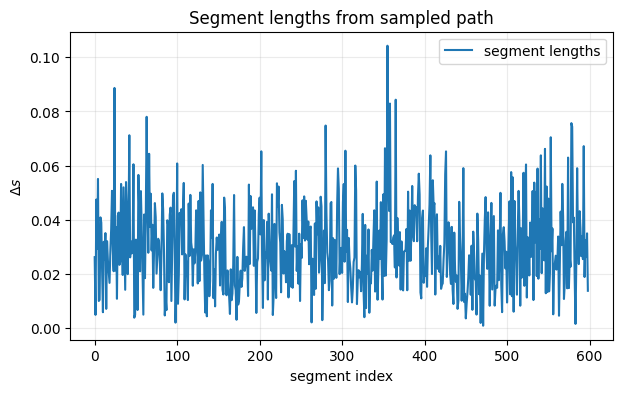

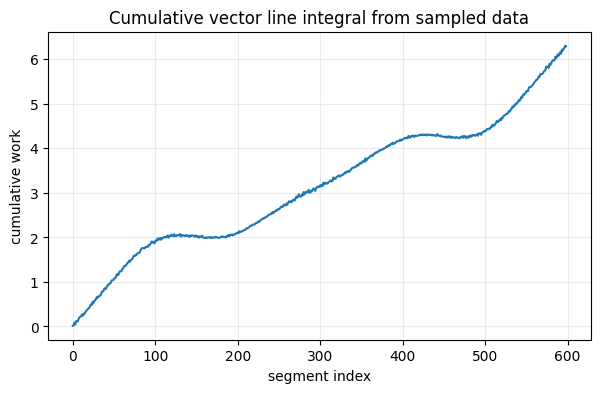

In [23]:
I_sample_scalar, midpoints, ds, values = sampled_scalar_line_integral(density_wire, sampled_path)
I_sample_vector, midpoints_v, dr, contrib = sampled_vector_line_integral(F_rotational, sampled_path)

print("Sampled scalar line integral with density_wire:", I_sample_scalar)
print("Sampled vector line integral in rotational field:", I_sample_vector)
print("Approximate polyline length:", np.sum(ds))

plt.figure(figsize=(7, 4))
plt.plot(ds, label="segment lengths")
plt.xlabel("segment index")
plt.ylabel(r"$\Delta s$")
plt.title("Segment lengths from sampled path")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(np.cumsum(contrib))
plt.xlabel("segment index")
plt.ylabel("cumulative work")
plt.title("Cumulative vector line integral from sampled data")
plt.grid(True, alpha=0.25)
plt.show()

## 18. Effect of sampling resolution

For a smooth path, finer sampling usually improves the polyline approximation.

In [24]:
def exact_like_path(t):
    return np.cos(t) + 0.4*np.cos(3*t), np.sin(t) + 0.2*np.sin(2*t)

def exact_like_path_derivative(t):
    return -np.sin(t) - 1.2*np.sin(3*t), np.cos(t) + 0.4*np.cos(2*t)

reference, *_ = vector_line_integral(F_rotational, exact_like_path, exact_like_path_derivative, 0, 2*np.pi, n=20000)

print("High-resolution reference:", reference)
for n in [30, 60, 120, 240, 480, 960]:
    tt = np.linspace(0, 2*np.pi, n)
    Xp, Yp = exact_like_path(tt)
    pts = np.column_stack([Xp, Yp])
    approx, *_ = sampled_vector_line_integral(F_rotational, pts)
    print(f"n={n:4d}, sampled approximation={approx:12.8f}, error={approx-reference: .3e}")

High-resolution reference: 6.283185307179586
n=  30, sampled approximation=  6.23414277, error=-4.904e-02
n=  60, sampled approximation=  6.27131565, error=-1.187e-02
n= 120, sampled approximation=  6.28026631, error=-2.919e-03
n= 240, sampled approximation=  6.28246158, error=-7.237e-04
n= 480, sampled approximation=  6.28300512, error=-1.802e-04
n= 960, sampled approximation=  6.28314036, error=-4.495e-05


---

# Part X. Work and energy in a force field

If a force field is conservative,

$$
\mathbf F=-\nabla U,
$$

where $U$ is potential energy.  
Then work done by the force is

$$
W=\int_C\mathbf F\cdot d\mathbf r=U(A)-U(B).
$$

The work depends only on the endpoints.

## 19. Spring force field

A two-dimensional Hooke-type spring force is

$$
\mathbf F(x,y)=\langle -kx,-ky\rangle.
$$

This is conservative:

$$
\mathbf F=-\nabla U,\qquad
U(x,y)=\frac{k}{2}(x^2+y^2).
$$

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Spring work along straight path: 1.75
Spring work along curved path: 1.7500003144736862
Energy drop U(A)-U(B): 1.75


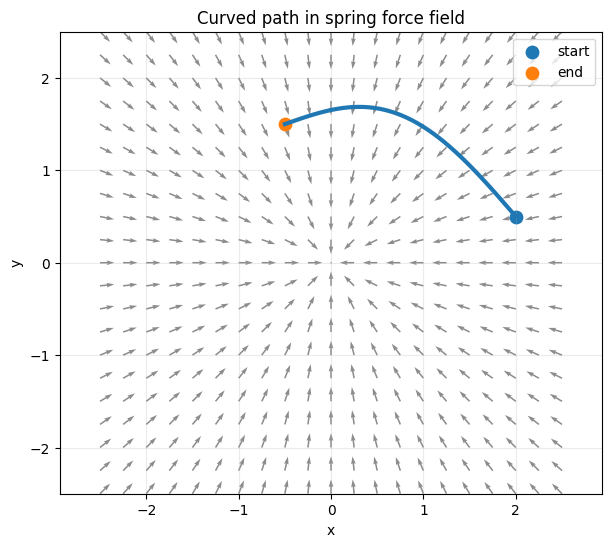

In [25]:
k = 2.0

def F_spring(X, Y):
    return -k*X, -k*Y

def U_spring(X, Y):
    return 0.5*k*(X**2 + Y**2)

A = np.array([2.0, 0.5])
B = np.array([-0.5, 1.5])

def r_spring_line(t):
    return A[0] + t*(B[0]-A[0]), A[1] + t*(B[1]-A[1])

def rp_spring_line(t):
    return (B[0]-A[0])*np.ones_like(t), (B[1]-A[1])*np.ones_like(t)

def r_spring_curve(t):
    x = A[0] + t*(B[0]-A[0])
    y = A[1] + t*(B[1]-A[1]) + 0.6*np.sin(np.pi*t)
    return x, y

def rp_spring_curve(t):
    dx = (B[0]-A[0])*np.ones_like(t)
    dy = (B[1]-A[1])*np.ones_like(t) + 0.6*np.pi*np.cos(np.pi*t)
    return dx, dy

W_line, *_ = vector_line_integral(F_spring, r_spring_line, rp_spring_line, 0, 1)
W_curve, *_ = vector_line_integral(F_spring, r_spring_curve, rp_spring_curve, 0, 1)
energy_drop = U_spring(A[0], A[1]) - U_spring(B[0], B[1])

print("Spring work along straight path:", W_line)
print("Spring work along curved path:", W_curve)
print("Energy drop U(A)-U(B):", energy_drop)

plot_path_in_vector_field(
    F_spring,
    r_spring_curve,
    0, 1,
    xmin=-2.5, xmax=2.5,
    ymin=-2.5, ymax=2.5,
    title="Curved path in spring force field"
)

---

# Part XI. Scalar line integrals in space

For a space curve

$$
\mathbf r(t)=\langle x(t),y(t),z(t)\rangle,
$$

the scalar line integral is still

$$
\int_C f\,ds
=
\int_a^b f(\mathbf r(t))|\mathbf r'(t)|\,dt.
$$

The speed is now

$$
|\mathbf r'(t)|=\sqrt{(x')^2+(y')^2+(z')^2}.
$$

## 20. Helix length and scalar line integral

Let

$$
\mathbf r(t)=\langle\cos t,\sin t,t\rangle,\qquad 0\leq t\leq4\pi.
$$

Then

$$
|\mathbf r'(t)|=\sqrt{(-\sin t)^2+(\cos t)^2+1^2}=\sqrt2.
$$

Helix length estimate: 17.771531752633464
Exact length: 17.771531752633464
Variable-density helix mass: 28.93771447205567


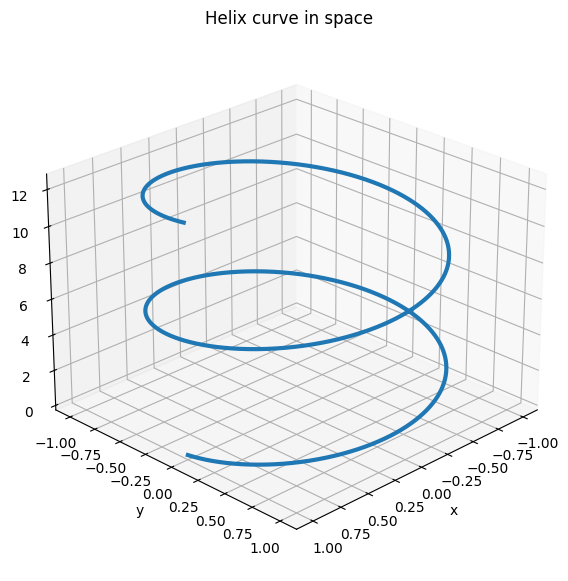

In [26]:
def r_helix(t):
    return np.cos(t), np.sin(t), t

def rp_helix(t):
    return -np.sin(t), np.cos(t), np.ones_like(t)

def scalar_line_integral_3d(f, r, rp, a, b, n=3000):
    t = np.linspace(a, b, n)
    X, Y, Z = r(t)
    dX, dY, dZ = rp(t)
    speed = np.sqrt(dX**2 + dY**2 + dZ**2)
    values = f(X, Y, Z)
    integrand = values*speed
    return float(np.trapezoid(integrand, t)), t, values, speed, integrand

def f_helix(X, Y, Z):
    return 1 + 0.1*Z

length_helix, t, ones_vals, speed_h, integrand_len = scalar_line_integral_3d(
    lambda X, Y, Z: np.ones_like(X), r_helix, rp_helix, 0, 4*np.pi
)

mass_helix, t, values_h, speed_h, integrand_h = scalar_line_integral_3d(
    f_helix, r_helix, rp_helix, 0, 4*np.pi
)

print("Helix length estimate:", length_helix)
print("Exact length:", 4*np.pi*np.sqrt(2))
print("Variable-density helix mass:", mass_helix)

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")
Xh, Yh, Zh = r_helix(t)
ax.plot(Xh, Yh, Zh, linewidth=3)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Helix curve in space")
ax.view_init(elev=25, azim=45)
plt.show()

---

# Part XII. Chapter mini-project: robot work along routes

A robot moves in a planar force field

$$
\mathbf F(x,y)
=
\langle
0.6-y+0.2x,\;
x+0.3y
\rangle.
$$

The robot travels from $A=(-2,-1)$ to $B=(2,1)$.

You will compare work along several routes:

1. straight line;
2. curved sinusoidal route;
3. piecewise route;
4. reversed route;
5. closed loop route.

Then you will decide whether the field appears conservative.

## 21. Define the force field and routes

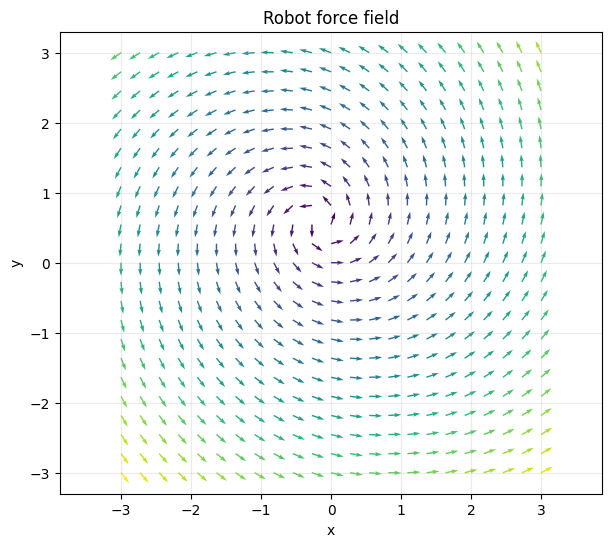

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


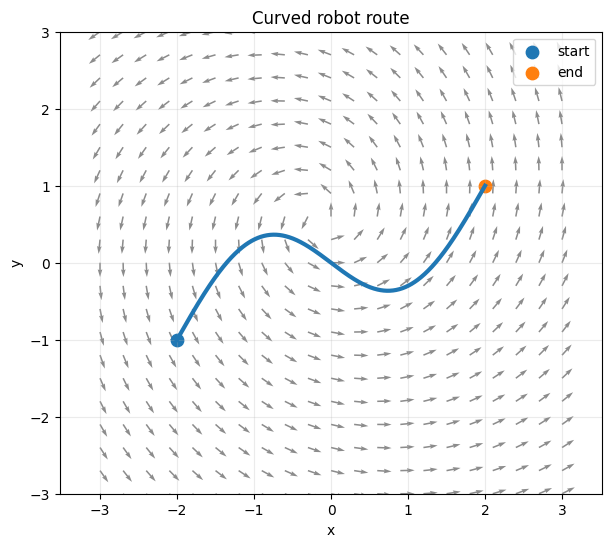

In [27]:
def F_robot(X, Y):
    return 0.6 - Y + 0.2*X, X + 0.3*Y

A_robot = np.array([-2.0, -1.0])
B_robot = np.array([2.0, 1.0])

def r_robot_straight(t):
    return A_robot[0] + t*(B_robot[0]-A_robot[0]), A_robot[1] + t*(B_robot[1]-A_robot[1])

def rp_robot_straight(t):
    return (B_robot[0]-A_robot[0])*np.ones_like(t), (B_robot[1]-A_robot[1])*np.ones_like(t)

def r_robot_curve(t):
    x = A_robot[0] + t*(B_robot[0]-A_robot[0])
    y = A_robot[1] + t*(B_robot[1]-A_robot[1]) + 0.8*np.sin(2*np.pi*t)
    return x, y

def rp_robot_curve(t):
    dx = (B_robot[0]-A_robot[0])*np.ones_like(t)
    dy = (B_robot[1]-A_robot[1])*np.ones_like(t) + 1.6*np.pi*np.cos(2*np.pi*t)
    return dx, dy

robot_piecewise = piecewise_points([A_robot, [-1, 1.5], [0.8, -1.2], B_robot], points_per_segment=350)

plot_vector_field(
    F_robot,
    xmin=-3, xmax=3,
    ymin=-3, ymax=3,
    n=23,
    normalize=True,
    title="Robot force field"
)

plot_path_in_vector_field(
    F_robot,
    r_robot_curve,
    0, 1,
    xmin=-3, xmax=3,
    ymin=-3, ymax=3,
    title="Curved robot route"
)

## 22. Compute work along routes

Work along straight route: 2.4
Work along curved route: 2.3999999999999995
Work along piecewise route: 1.5999999999999996


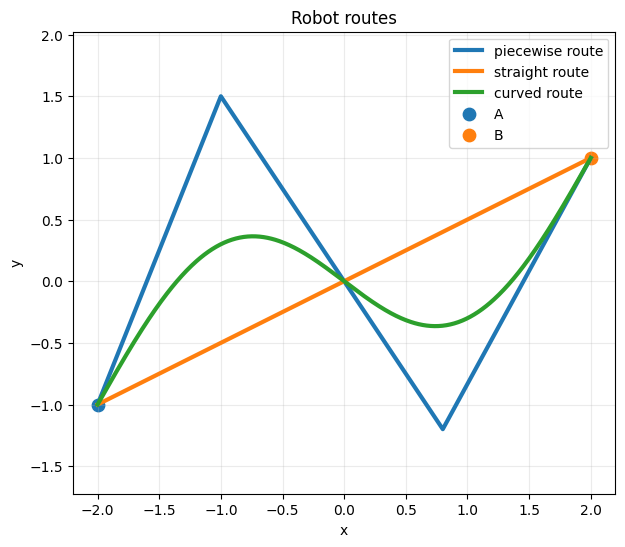

In [28]:
W_robot_straight, *_ = vector_line_integral(F_robot, r_robot_straight, rp_robot_straight, 0, 1, n=3000)
W_robot_curve, *_ = vector_line_integral(F_robot, r_robot_curve, rp_robot_curve, 0, 1, n=3000)
W_robot_piecewise, *_ = sampled_vector_line_integral(F_robot, robot_piecewise)

print("Work along straight route:", W_robot_straight)
print("Work along curved route:", W_robot_curve)
print("Work along piecewise route:", W_robot_piecewise)

plt.figure(figsize=(7, 6))
plt.plot(robot_piecewise[:,0], robot_piecewise[:,1], linewidth=3, label="piecewise route")
t = np.linspace(0, 1, 500)
xs, ys = r_robot_straight(t)
xc, yc = r_robot_curve(t)
plt.plot(xs, ys, linewidth=3, label="straight route")
plt.plot(xc, yc, linewidth=3, label="curved route")
plt.scatter([A_robot[0]], [A_robot[1]], s=80, label="A")
plt.scatter([B_robot[0]], [B_robot[1]], s=80, label="B")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Robot routes")
plt.axis("equal")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

## 23. Reversed route and closed-loop work

In [29]:
robot_piecewise_reverse = robot_piecewise[::-1]
W_robot_reverse, *_ = sampled_vector_line_integral(F_robot, robot_piecewise_reverse)

closed_loop = np.vstack([robot_piecewise, robot_piecewise_reverse[1:]])
W_robot_closed, *_ = sampled_vector_line_integral(F_robot, closed_loop)

print("Piecewise route work A to B:", W_robot_piecewise)
print("Reversed route work B to A:", W_robot_reverse)
print("Sum:", W_robot_piecewise + W_robot_reverse)
print("Closed-loop work using path plus reverse:", W_robot_closed)

Piecewise route work A to B: 1.5999999999999996
Reversed route work B to A: -1.5999999999999992
Sum: 4.440892098500626e-16
Closed-loop work using path plus reverse: 8.881784197001252e-16


## 24. Conservative check by scalar curl

For

$$
\mathbf F=\langle P,Q\rangle,
$$

a necessary condition for conservativeness on a simply connected region is

$$
P_y=Q_x.
$$

For the robot field,

$$
P=0.6-y+0.2x,\qquad Q=x+0.3y.
$$

Thus

$$
P_y=-1,\qquad Q_x=1.
$$

So the field is not conservative.

In [30]:
def numerical_scalar_curl(F, X, Y, h=1e-5):
    P = lambda x, y: F(x, y)[0]
    Q = lambda x, y: F(x, y)[1]
    Qx = (Q(X+h, Y) - Q(X-h, Y))/(2*h)
    Py = (P(X, Y+h) - P(X, Y-h))/(2*h)
    return Qx - Py

for p in [(-2,-1), (0,0), (2,1), (1.5,-0.5)]:
    curl = numerical_scalar_curl(F_robot, p[0], p[1])
    print("point:", p, "scalar curl:", curl)

point: (-2, -1) scalar curl: 2.0000000000131024
point: (0, 0) scalar curl: 1.999999999995449
point: (2, 1) scalar curl: 2.0000000000075513
point: (1.5, -0.5) scalar curl: 2.000000000002


## 25. Mini-project questions

Answer the following in a markdown cell:

1. Which robot route required the most work?
2. Which route required the least work?
3. Why does reversing a path change the sign of the work?
4. Does the robot force field appear conservative? Why or why not?
5. What does nonzero closed-loop circulation mean physically?
6. How would you choose a route that reduces work in this field?

In [31]:
print("Robot mini-project summary")
print("--------------------------")
print("Straight route work:", W_robot_straight)
print("Curved route work:", W_robot_curve)
print("Piecewise route work:", W_robot_piecewise)
print("Reverse piecewise route work:", W_robot_reverse)
print("Path dependence range:", max(W_robot_straight, W_robot_curve, W_robot_piecewise) - min(W_robot_straight, W_robot_curve, W_robot_piecewise))
print("Scalar curl of robot field is approximately 2 everywhere.")

Robot mini-project summary
--------------------------
Straight route work: 2.4
Curved route work: 2.3999999999999995
Piecewise route work: 1.5999999999999996
Reverse piecewise route work: -1.5999999999999992
Path dependence range: 0.8000000000000003
Scalar curl of robot field is approximately 2 everywhere.


---

# Part XIII. Additional exercises with reference solutions

Try each exercise before running the reference solution.

## Exercise A. Arc length

Compute the arc length of

$$
\mathbf r(t)=\langle t,\sin t\rangle,
\qquad 0\leq t\leq 2\pi.
$$

In [32]:
# Exercise A workspace

# Your code here

### Reference solution for Exercise A

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Arc length estimate: 7.640395578055424


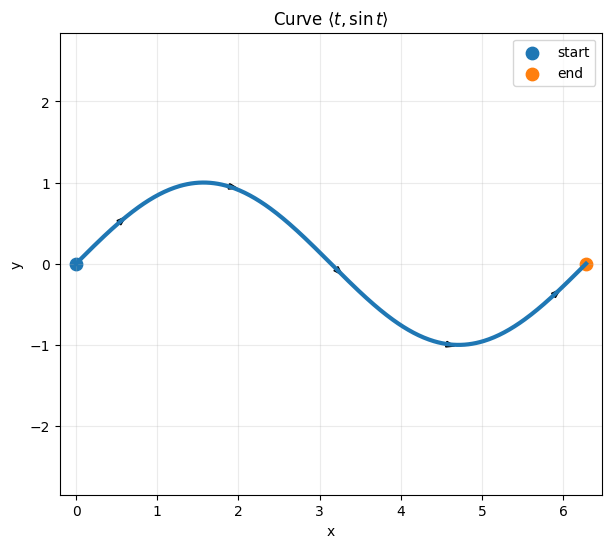

array([[ 0.      ,  0.      ],
       [ 0.015747,  0.015747],
       [ 0.031495,  0.031489],
       [ 0.047242,  0.047224],
       [ 0.062989,  0.062948],
       [ 0.078737,  0.078655],
       [ 0.094484,  0.094343],
       [ 0.110231,  0.110008],
       [ 0.125979,  0.125646],
       [ 0.141726,  0.141252],
       [ 0.157473,  0.156823],
       [ 0.173221,  0.172356],
       [ 0.188968,  0.187845],
       [ 0.204715,  0.203288],
       [ 0.220463,  0.218681],
       [ 0.23621 ,  0.23402 ],
       [ 0.251957,  0.2493  ],
       [ 0.267705,  0.264519],
       [ 0.283452,  0.279672],
       [ 0.299199,  0.294755],
       [ 0.314947,  0.309766],
       [ 0.330694,  0.324699],
       [ 0.346441,  0.339553],
       [ 0.362189,  0.354322],
       [ 0.377936,  0.369003],
       [ 0.393683,  0.383593],
       [ 0.409431,  0.398087],
       [ 0.425178,  0.412483],
       [ 0.440925,  0.426776],
       [ 0.456673,  0.440964],
       [ 0.47242 ,  0.455043],
       [ 0.488167,  0.469008],
       [

In [33]:
def r_A(t):
    return t, np.sin(t)

def rp_A(t):
    return np.ones_like(t), np.cos(t)

L_A, *_ = arc_length(rp_A, 0, 2*np.pi, n=5000)
print("Arc length estimate:", L_A)

plot_curve(r_A, 0, 2*np.pi, xmin=-0.2, xmax=2*np.pi+0.2, ymin=-1.3, ymax=1.3,
           title=r"Curve $\langle t,\sin t\rangle$")

## Exercise B. Scalar line integral

Compute

$$
\int_C y\,ds
$$

where $C$ is the line segment from $(0,0)$ to $(1,2)$.

In [34]:
# Exercise B workspace

# Your code here

### Reference solution for Exercise B

In [35]:
def r_B(t):
    return t, 2*t

def rp_B(t):
    return np.ones_like(t), 2*np.ones_like(t)

def f_B(X, Y):
    return Y

I_B, *_ = scalar_line_integral(f_B, r_B, rp_B, 0, 1)
print("Numerical value:", I_B)

# Exact: y=2t, speed=sqrt(5), integral ∫0^1 2t sqrt(5) dt = sqrt(5).
print("Exact value:", np.sqrt(5))

Numerical value: 2.23606797749979
Exact value: 2.23606797749979


## Exercise C. Work integral

Compute

$$
\int_C \langle y,x\rangle\cdot d\mathbf r
$$

where $C$ is the parabola

$$
\mathbf r(t)=\langle t,t^2\rangle,\qquad 0\leq t\leq1.
$$

In [36]:
# Exercise C workspace

# Your code here

### Reference solution for Exercise C

In [37]:
def F_C(X, Y):
    return Y, X

I_C, *_ = vector_line_integral(F_C, r_parabola_01, rp_parabola_01, 0, 1)
print("Numerical value:", I_C)

# Along path: F=<t^2,t>, r'=<1,2t>, dot=t^2+2t^2=3t^2.
# Integral = 1.
print("Exact value:", 1.0)

Numerical value: 1.0000001251250938
Exact value: 1.0


## Exercise D. Conservative field

Let

$$
\mathbf F(x,y)=\langle e^x\cos y,\;-e^x\sin y\rangle.
$$

This is the gradient of

$$
f(x,y)=e^x\cos y.
$$

Compute the work from $(0,0)$ to $(1,\pi/2)$.

In [38]:
# Exercise D workspace

# Your code here

### Reference solution for Exercise D

In [39]:
def F_D(X, Y):
    return np.exp(X)*np.cos(Y), -np.exp(X)*np.sin(Y)

A_D = np.array([0.0, 0.0])
B_D = np.array([1.0, np.pi/2])

def r_D(t):
    return A_D[0] + t*(B_D[0]-A_D[0]), A_D[1] + t*(B_D[1]-A_D[1])

def rp_D(t):
    return (B_D[0]-A_D[0])*np.ones_like(t), (B_D[1]-A_D[1])*np.ones_like(t)

I_D, *_ = vector_line_integral(F_D, r_D, rp_D, 0, 1, n=4000)
potential_difference = np.exp(1)*np.cos(np.pi/2) - np.exp(0)*np.cos(0)

print("Work estimate:", I_D)
print("Potential difference:", potential_difference)

Work estimate: -1.0000000368534927
Potential difference: -0.9999999999999999


## Exercise E. Circulation

Compute the circulation of

$$
\mathbf F(x,y)=\langle -2y,2x\rangle
$$

around the circle of radius $3$ counterclockwise.

In [40]:
# Exercise E workspace

# Your code here

### Reference solution for Exercise E

In [41]:
def F_E(X, Y):
    return -2*Y, 2*X

def r_E(t):
    return 3*np.cos(t), 3*np.sin(t)

def rp_E(t):
    return -3*np.sin(t), 3*np.cos(t)

I_E, *_ = vector_line_integral(F_E, r_E, rp_E, 0, 2*np.pi, n=5000)
print("Numerical circulation:", I_E)

# Along circle, F=< -6 sin t, 6 cos t>, r'=< -3 sin t, 3 cos t>
# dot = 18, integral = 36π.
print("Exact circulation:", 36*np.pi)

Numerical circulation: 113.09733552923255
Exact circulation: 113.09733552923255


---

# Formula summary

## Arc length

For

$$
\mathbf r(t)=\langle x(t),y(t)\rangle,
$$

the speed is

$$
|\mathbf r'(t)|=\sqrt{(x'(t))^2+(y'(t))^2},
$$

and the arc length is

$$
L=\int_a^b|\mathbf r'(t)|\,dt.
$$

## Scalar line integral

$$
\int_C f\,ds
=
\int_a^b f(\mathbf r(t))|\mathbf r'(t)|\,dt.
$$

## Vector line integral

$$
\int_C\mathbf F\cdot d\mathbf r
=
\int_a^b\mathbf F(\mathbf r(t))\cdot\mathbf r'(t)\,dt.
$$

## Work

If $\mathbf F$ is a force field, then

$$
W=\int_C\mathbf F\cdot d\mathbf r.
$$

## Orientation

Reversing orientation changes the sign of a vector line integral:

$$
\int_{-C}\mathbf F\cdot d\mathbf r
=
-\int_C\mathbf F\cdot d\mathbf r.
$$

Scalar line integrals are unchanged by orientation reversal:

$$
\int_{-C}f\,ds=\int_Cf\,ds.
$$

## Conservative fields

If

$$
\mathbf F=\nabla f,
$$

then

$$
\int_C\mathbf F\cdot d\mathbf r=f(B)-f(A).
$$

## Circulation

For a closed curve $C$,

$$
\oint_C\mathbf F\cdot d\mathbf r
$$

measures circulation around $C$.

# End of Chapter 20 Lab

You have used Python to explore:

- parametrized curves,
- arc length,
- scalar line integrals,
- variable-density wires,
- vector line integrals and work,
- orientation and reparametrization,
- conservative fields and path independence,
- nonconservative path dependence,
- circulation around closed curves,
- piecewise paths,
- line integrals from sampled data,
- work and potential energy,
- scalar line integrals in space,
- and a robot-work mini-project.

These ideas prepare for Green's theorem, flux integrals, curl, divergence, and the major theorems of vector calculus.